In [2]:
import librosa
import numpy as np
from src.utils.utils import *

c:\Users\ernun\VoicePathologyClassification\VoicePathologyClassification\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
voice001r, sr001 = librosa.load(r"C:\Users\ernun\VoicePathologyClassification\VoicePathologyClassification\data\raw\voice001.wav",sr=None)
voice002r, sr002 = librosa.load(r"C:\Users\ernun\VoicePathologyClassification\VoicePathologyClassification\data\raw\voice002.wav",sr=None)

### Calculating Fundamental Frequency

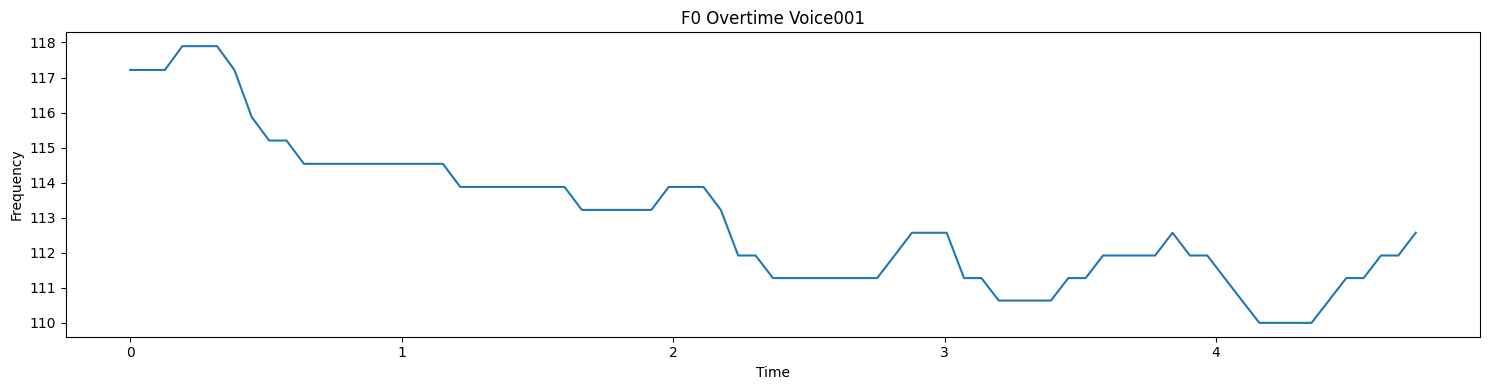

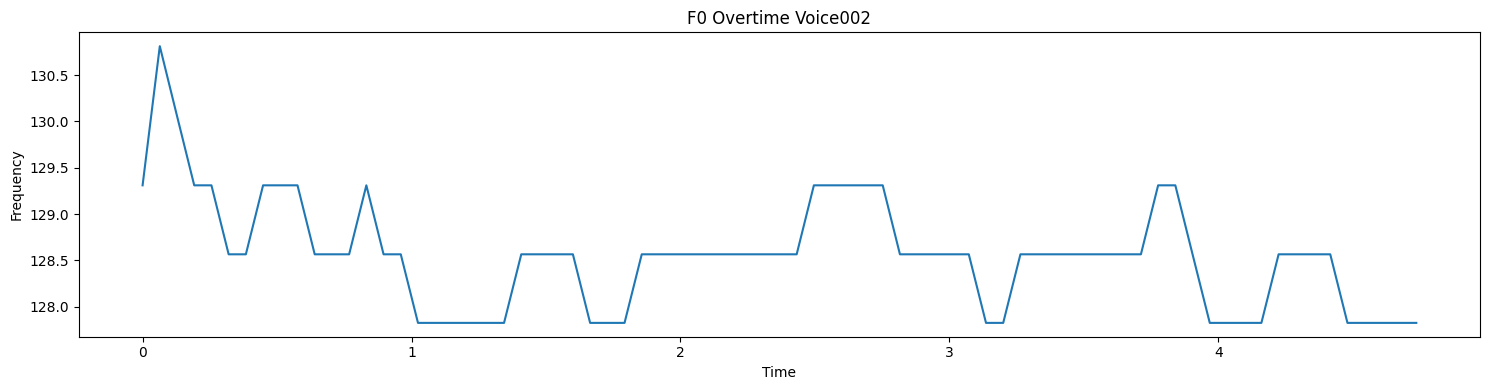

In [9]:
f01, l, _ =librosa.pyin(voice001r, sr=sr001, fmin=librosa.note_to_hz('C2'),fmax=librosa.note_to_hz('C7'))
time001 = librosa.times_like(f01, sr=sr001)

f02,l,_ = librosa.pyin(voice002r,sr=sr002,fmin=librosa.note_to_hz('C2'),fmax=librosa.note_to_hz('C7'))
time002 = librosa.times_like(f02, sr=sr002)

# defining function for F0
def extract_f0(audio, sample_rate):
    f0, _, _ = librosa.pyin(audio, 
                            sr = sample_rate, 
                            fmin = librosa.note_to_hz('C2'),
                            fmax=librosa.note_to_hz('C7')
                            )
    return f0

plt.figure(figsize=(15,4))
plt.plot(time001,f01)
plt.title("F0 Overtime Voice001")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,4))
plt.plot(time002, f02)
plt.title("F0 Overtime Voice002")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Calculating Jitter

In [ ]:
# local jitter = mean(abs(period(i)-period(i+1))) / mean(period(i))
periods01 = 1/f01
diff01 = np.abs(np.diff(periods01))

ljitter01 = np.mean(diff01) / np.mean(periods01)
print(ljitter01)

def extract_local_jitter(audio, sample_rate):
    f0 = extract_f0(audio, sample_rate)

    f0 = f0[~np.isnan(f0)]
    f0 = f0[f0 > 0]

    periods = 1/f0

    if len(periods) < 2:
        return np.nan

    difference = np.abs(np.diff(periods))

    return np.mean(difference) / np.mean(periods)

# RAP jitter (relative average perturbation)
diffrap01 = []
for i in range(1,len(periods01)-1):
    avg_3 = (periods01[i-1] + periods01[i] + periods01[i+1])/3
    diffrap01.append(np.abs(periods01[i] - avg_3))

rap = np.mean(diffrap01) / np.mean(periods01)
print(rap)

def extract_rap_jitter(audio_arr, sample_rate):
    f0 = extract_f0(audio_arr, sample_rate)

    f0 = f0[~np.isnan(f0)]
    f0 = f0[f0 > 0]

    periods = 1/f0
    rap_terms = []

    if len(periods) < 3:
        return np.nan

    for i in range(1, len(periods) - 1):
        avg = (periods[i-1] + periods[i] + periods[i+1]) / 3
        rap_terms.append(np.abs(periods[i] - avg))

    return np.mean(rap_terms) / np.mean(periods)  

print(extract_local_jitter(voice001r, sr001))
print(extract_rap_jitter(voice001r, sr001))

# PPQ5 Jitter (pitch perturbation quotient, 5 points)
def extract_ppq5_jitter(audio_arr: np.ndarray, sample_rate: int) -> float:
    f0 = extract_f0(audio_arr, sample_rate)

    f0 = f0[~np.isnan(f0)]
    f0 = f0[f0 > 0]

    periods = 1/f0
    ppq5_terms = []

    if len(periods) < 5:
        return np.nan
    
    for i in range(2, len(periods) - 2):
        avg = (periods[i-2] + periods[i-1] + periods[i] + periods[i+1] + periods[i+2]) / 5
        ppq5_terms.append(np.abs(periods[i] - avg))
    
    return np.mean(ppq5_terms) / np.mean(periods)

print(extract_ppq5_jitter(voice001r, sr001))

0.002265426700299488
0.0011358600530351265
0.002265426700299488
0.0011358600530351265
0.0017076023055506205


np.float64(1.0)

### Experiment on different voice

In [34]:
voice148, sr148 = librosa.load(r"C:\Users\ernun\VoicePathologyClassification\VoicePathologyClassification\data\processed\148-phrase.wav",sr=None)
print(extract_f0(voice148,sr148))

print(extract_local_jitter(voice148, sr148))
print(extract_rap_jitter(voice148,sr148))
print(extract_ppq5_jitter(voice148,sr148))








[         nan 258.62053938 257.13099468 254.17759331 254.17759331
 252.7136381  235.79016176 210.06515286 199.42369775 193.74649219
 192.63059451 193.74649219 195.99771799 199.42369775 201.74088951
 205.26725814 211.28204791 227.75828325 238.52991147 238.52991147
 238.52991147 233.08188076 238.52991147 238.52991147 238.52991147
 237.15608027 225.14225624 226.44649206 229.07767356 222.55627687
 221.27444703 220.         220.         218.73289324 217.47308448
 168.66611791 169.64319079 168.66611791 169.64319079 169.64319079
 164.81377846          nan 173.60841241 174.61411572 181.81906999
 180.77186921 176.64303401 172.60850154 171.61434972 171.61434972
 172.60850154 176.64303401 179.73069986 182.87233715 184.99721136
 183.93170582]
0.023023346386068864
0.010149177735431449
0.01777657663919094


### Calculating Shimmer